# Heuristics — EV2Gym V2G Profit Maximization Benchmark

**Algorithms:** AFAP · ALAP · Round Robin
**Type:** deterministic rule-based policies · no learning · no HPO
**Scenario:** Workplace · 10 charging stations · 85 steps × 15 min
**Reference:** Orfanoudakis et al. 2025 (arXiv:2404.01849), Table VII

## Algorithms

- **AFAP (As Fast As Possible):** charges each EV at maximum rate immediately after
  connection. V2G-unaware — never discharges. Maximises user satisfaction at the
  cost of large transformer overloads.
- **ALAP (As Late As Possible):** delays charging to the latest feasible start time.
  V2G-unaware. Avoids peak-hour overload but may miss high-price discharge windows.
- **Round Robin (RR):** distributes available capacity evenly across connected EVs.
  V2G-unaware. Serves as a low-complexity fairness reference.

These baselines define the lower performance bound for RL agents — they act without
V2G awareness and without price signal exploitation.

**Paper results (Table VII):**
- AFAP: profit = −23.4 ± 6.4 € · sat = 100 % · overload = 138 ± 86 kWh
- ALAP: profit = −25.2 ± 7.1 € · sat = 100 % · overload = 106 ± 78 kWh
- RR:   profit = −22.6 ± 5.6 € · sat = 99 % ·  overload = 11 ± 19 kWh

## Protocol

5 seeds × 20 episodes = 100 episodes per heuristic. Seeds `[42, 123, 999, 7, 89]`.
Heuristics are deterministic given a seed — variance reflects stochastic EV arrivals
and prices only. No VecNormalize, no HPO.

## How to run

Set `MODE = 'PROD'` in Cell 1. Runtime is short (< 30 min) relative to RL notebooks.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  MODE CONFIGURATION
#  Set MODE = 'TEST' to verify correctness end-to-end (minutes)
#  Set MODE = 'PROD' for the full publishable run (hours)
# ═══════════════════════════════════════════════════════════════════════════

MODE = 'PROD'   # <-- change to 'PROD' for production

if MODE == 'TEST':
    EVAL_SEEDS        = [42, 123]                  # PROD: [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 5                          # PROD: 20
else:
    EVAL_SEEDS        = [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 20

EVAL_EPISODES = len(EVAL_SEEDS) * EPISODES_PER_SEED
print(f'Mode: {MODE}')
print(f'Evaluation: {len(EVAL_SEEDS)} seeds x {EPISODES_PER_SEED} eps = {EVAL_EPISODES} eps/agente')


Mode: PROD
Evaluation: 5 seeds x 20 eps = 100 eps/agente


In [2]:
import json, time, warnings, random
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import gymnasium as gym
warnings.filterwarnings('ignore')

from ev2gym.rl_agent.reward import profit_maximization
from ev2gym.rl_agent.state  import V2G_profit_max
from ev2gym.baselines.heuristics import (
    ChargeAsFastAsPossible,
    ChargeAsLateAsPossible,
    RoundRobin,
)

RESULTS_ROOT = Path('results_heuristics_model1')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print('Results in:', RESULTS_ROOT)

# ── Reproducibility log ──────────────────────────────────────────────────────
REPRO_LOG = {
    'algorithms': ['AFAP', 'ALAP', 'RR'],
    'algorithm_type': 'deterministic heuristics — no HPO, no VecNormalize, no replay buffer',
    'heuristic_notes': {
        'AFAP': 'Charges at maximum rate immediately. V2G-unaware (never discharges).',
        'ALAP': 'Delays charging to latest feasible time. V2G-unaware.',
        'RR': 'Distributes capacity evenly via RoundRobinM1 (Model-1 fix). V2G-unaware. Stock RoundRobin reads power_setpoints=0 in Model-1, charging 0 EVs. RoundRobinM1 injects transformer capacity as power budget.'
    },
    'no_hpo': True,
    'no_vecnormalize': True,
    'no_proxy_reward': True,
    'evaluation_reward': 'Model-1 (sparse): r_t = c_{t-1} - 100*eps_ov - 100*exp(-10*eps_usr)',
    'eval_seeds': [42, 123, 999, 7, 89],
    'episodes_per_seed': 20,
    'total_eval_episodes_per_agent': 100,  # 5 seeds x 20 eps
    'seed_formula': 'eval_seed * 1000 + ep_counter (unique per (seed, episode) pair)',
    'mpc_horizon_note': 'EV2Gym paper MPC uses horizon=25 steps (Table VII §V-B). '
                        'Our reproduced MPC variant could not match that config — treated as a distinct controller.',
    'paper_refs_verified': {
        'AFAP': {'profit_mean': -23.4, 'profit_std': 6.4, 'sat_mean': 1.0,
                 'overload_mean': 138.0, 'overload_std': 86.0, 'Qlost_mean': 0.40e-3},
        'ALAP': {'profit_mean': -25.2, 'profit_std': 7.1, 'sat_mean': 1.0,
                 'overload_mean': 106.0, 'overload_std': 78.0, 'Qlost_mean': 0.38e-3},
        'RR':   {'profit_mean': -22.6, 'profit_std': 5.6, 'sat_mean': 0.99,
                 'overload_mean': 11.0,  'overload_std': 19.0, 'Qlost_mean': 0.45e-3},
    },
    'statistical_note': 'Heuristics are deterministic given a seed. Variance reflects '
                         'stochastic EV arrivals and prices only. No significance testing '
                         'applies to comparisons between heuristics and RL agents.',
}
print('Reproducibility log initialized.')


Results in: results_heuristics_model1
Reproducibility log initialized.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# YAML Model 1 embebido
#  charging_network_topology = 'None' → EV2Gym generates a random network topology
#
#  MPC HORIZON NOTE:
#  The EV2Gym paper (Table VII) uses the rolling-horizon MPC controller
#  (V2GProfitMaxOracle) with prediction+control horizon of 25 steps (§V-B).
#  Our reproduced MPC variant could not unambiguously match that config,
#  so it is treated as a distinct controller — not a faithful replication.
#  This explains the sign reversal in profit (+17.8 paper vs -7.6 ours).
# ─────────────────────────────────────────────────────────────────────────────

MODEL1_YAML_STR = """timescale: 15
simulation_length: 85
year: 2022
month: 1
day: 17
random_day: true
random_hour: false
hour: 7
minute: 0
simulation_days: weekdays
scenario: workplace
spawn_multiplier: 3
discharge_price_factor: 1
v2g_enabled: true
number_of_charging_stations: 10
number_of_transformers: 1
number_of_ports_per_cs: 1
charging_network_topology: None
simulate_grid: false
power_setpoint_enabled: false
inflexible_loads:
  include: false
  inflexible_loads_capacity_multiplier_mean: 1
  forecast_mean: 30
  forecast_std: 5
solar_power:
  include: false
  solar_power_capacity_multiplier_mean: 1
  forecast_mean: 20
  forecast_std: 5
demand_response:
  include: false
  events_per_day: 1
  event_capacity_percentage_mean: 35
  event_capacity_percentage_std: 5
  event_length_minutes_min: 60
  event_length_minutes_max: 60
  event_start_hour_mean: 12
  event_start_hour_std: 2
  notification_of_event_minutes: 60
heterogeneous_ev_specs: false
ev_specs_file: ./ev2gym/data/ev_specs_v2g_enabled2024.json
transformer:
  max_power: 200
charging_station:
  min_charge_current: 0
  max_charge_current: 32
  min_discharge_current: 0
  max_discharge_current: -32
  voltage: 400
  phases: 3
ev:
  battery_capacity: 70
  max_ac_charge_power: 22
  min_ac_charge_power: 0
  max_dc_charge_power: 50
  max_discharge_power: -22
  min_discharge_power: 0
  ev_phases: 3
  charge_efficiency: 1
  discharge_efficiency: 1
  transition_soc: 1
  min_battery_capacity: 15
  min_time_of_stay: 200
  min_emergency_battery_capacity: 15
  desired_capacity: 1
  transition_soc_multiplier: 50
tr_seed: -1
"""

def save_cfg(cfg, path):
    out = {}
    for k, v in cfg.items():
        if k == 'charging_network_topology':
            out[k] = 'None' if (v is None or str(v) == 'None') else str(v)
        elif isinstance(v, dict): out[k] = v
        elif v is None: continue
        else: out[k] = v
    with open(path, 'w') as f:
        yaml.dump(out, f, default_flow_style=False, allow_unicode=True)
    return str(path)

BASE_CFG = yaml.safe_load(MODEL1_YAML_STR)
MODEL1_YAML_PATH = RESULTS_ROOT / 'model1_base.yaml'
save_cfg(BASE_CFG, MODEL1_YAML_PATH)
CONFIG_FILE = str(MODEL1_YAML_PATH)
print('YAML saved to:', MODEL1_YAML_PATH)


YAML saved to: results_heuristics_model1/model1_base.yaml


In [4]:
# OVERLOAD KEY NOTE: The key "total_transformer_overload" is confirmed correct
# (source: ev2gym/utilities/utils.py). In TEST mode, transformer_overload_kwh
# is 0 for all agents because: YAML transformer.max_power=200 kW, and in
# TEST episodes only 3-6 EVs connect simultaneously (3-6 x 22 kW = 66-132 kW),
# well below the 200 kW limit. Overload appears in PROD when agents are fully
# trained and push more energy, or when spawn_multiplier yields many EVs.
# The key access pattern final_info.get("total_transformer_overload", 0.0)
# is correct and returns the actual value when > 0.

# ─────────────────────────────────────────────────────────────────────────────
# Metrics + evaluador de episodio
#
#  IMPORTANT: the heuristic agent is instantiated ONCE at the start
#  of the episode (after env.reset), NOT at each step.
#  RoundRobin is stateful (current turn) and must persist
#  throughout the episode. Re-instantiating it each step resets
#  estado y produce acciones cero.
#
#  agent_factory_fn(raw) -> agente con .get_action(raw)
#  Called once after env.reset(); the same object is reused across all steps.
# ─────────────────────────────────────────────────────────────────────────────

SCALAR_COLS = [
    'reward_total', 'total_profit_cost', 'user_satisfaction',
    'energy_charged_kwh', 'energy_discharged_kwh',
    'transformer_overload_kwh', 'battery_degradation',
    'battery_deg_calendar', 'battery_deg_cyclic',
    'total_ev_served', 'exec_time_s',
]

def run_episode_full(agent_factory_fn, config_file, ep_idx=0, eval_seed=42):
    """
    Run one heuristic episode. The agent is instantiated ONCE after env.reset(),
    then reused for all steps. This is essential for stateful agents like
    RoundRobin which track which EV gets the next turn.
    """
    t_start = time.time()
    env = gym.make('EV2Gym-v1', config_file=config_file,
                   reward_function=profit_maximization,
                   state_function=V2G_profit_max)
    obs, _ = env.reset(seed=eval_seed)
    raw   = env.unwrapped
    agent = agent_factory_fn(raw)  # instantiate ONCE con el env ya reseteado
    ts_reward = []; ts_action = []
    cum_reward = 0.0
    done = trunc = False
    final_info = {}
    while not (done or trunc):
        action = agent.get_action(raw)  # same agent instance at every step
        obs, reward, done, trunc, info = env.step(action)
        cum_reward += float(reward)
        ts_reward.append(float(reward))
        ts_action.append(float(np.mean(action)) if hasattr(action, '__len__') else float(action))
        if done or trunc:
            final_info = info
    exec_time = time.time() - t_start
    env.close()
    return {
        'episode'    : ep_idx,
        'n_steps'    : len(ts_reward),
        'exec_time_s': round(exec_time, 3),
        'reward_total'            : cum_reward,
        'total_profit_cost'       : float(final_info.get('total_profits',             0.0) or 0.0),
        'user_satisfaction'       : float(final_info.get('average_user_satisfaction', 0.0) or 0.0),
        'energy_charged_kwh'      : float(final_info.get('total_energy_charged',      0.0) or 0.0),
        'energy_discharged_kwh'   : float(final_info.get('total_energy_discharged',   0.0) or 0.0),
        'transformer_overload_kwh': float(final_info.get('total_transformer_overload',0.0) or 0.0),
        'battery_degradation'     : float(final_info.get('battery_degradation',       0.0) or 0.0),
        'battery_deg_calendar'    : float(final_info.get('battery_degradation_calendar', 0.0) or 0.0),
        'battery_deg_cyclic'      : float(final_info.get('battery_degradation_cycling',  0.0) or 0.0),
        'total_ev_served'         : float(final_info.get('total_ev_served',           0.0) or 0.0),
        'ts_reward'    : ts_reward,
        'ts_action'    : ts_action,
        'ts_cum_reward': list(np.cumsum(ts_reward)),
    }

print('Evaluator ready (agent instantiated once per episode).')


Evaluator ready (agent instantiated once per episode).


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Factories de heuristics
#
#  Each factory is a function que recibe raw (el env ya reseteado)
#  y returns the instantiated agent. run_episode_full llama a esta
#  function ONCE at the start of the episode.
#
#  AFAP/ALAP: stateless between steps.
#  RoundRobin: stateful (current turn) — must be the same instance
#  throughout the episode.
#
#  BUG FIX (RoundRobinM1): RoundRobin.get_action() reads
#  env.power_setpoints[t] to determine how many EVs to charge.
#  In Model-1, power_setpoint_enabled=False so setpoints are all 0.
#  Stock RoundRobin therefore charges 0 EVs: profit=+0.00 while EVs
#  depart at their arrival SoC. RoundRobinM1 injects transformer
#  capacity as the power budget to restore correct behaviour.
# ─────────────────────────────────────────────────────────────────────────────

TRAFO_KW = float(BASE_CFG.get("transformer", {}).get("max_power", 200))


class RoundRobinM1:
    """
    RoundRobin adapted for Model-1 (power_setpoint_enabled=False).

    RoundRobin uses env.power_setpoints[t] to size the charging budget.
    In Model-1, power_setpoints are all zeros -> stock RR charges 0 EVs
    -> profit=+0.00 (no energy exchanged). This wrapper injects the
    transformer max power so RR operates correctly.
    """
    def __init__(self, env):
        self._rr = RoundRobin(env)
        self._trafo_kw = TRAFO_KW

    def get_action(self, env) -> np.ndarray:
        orig = env.power_setpoints[env.current_step]
        env.power_setpoints[env.current_step] = self._trafo_kw
        action = self._rr.get_action(env)
        env.power_setpoints[env.current_step] = orig
        return action


def make_afap_fn():
    """As Fast As Possible: charges at maximum rate immediately."""
    return lambda raw: ChargeAsFastAsPossible()


def make_alap_fn():
    """As Late As Possible: delays charging to latest feasible start time."""
    return lambda raw: ChargeAsLateAsPossible()


def make_rr_fn():
    """
    Round Robin adapted for Model-1 via RoundRobinM1 wrapper.
    RoundRobin(env) is instantiated once per episode after env.reset().
    The internal state (current turn) persists for the entire episode.
    """
    return lambda raw: RoundRobinM1(raw)


AGENTS = {
    'AFAP': make_afap_fn,
    'ALAP': make_alap_fn,
    'RR'  : make_rr_fn,
}
print('Heuristics ready:', list(AGENTS.keys()))
print('NOTE: AFAP/ALAP/RR are V2G-unaware (never discharge).')
print(f'RoundRobinM1 uses transformer capacity: {TRAFO_KW} kW')


Heuristics ready: ['AFAP', 'ALAP', 'RR']
NOTE: AFAP/ALAP/RR are V2G-unaware (never discharge).
RoundRobinM1 uses transformer capacity: 200.0 kW


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation
#  4 seeds × 25 episodes = 100 episodes per heuristic
#  Seed formula: eval_seed * 1000 + ep_counter (unique per (seed, ep) pair)
#   an earlier version used seed + ep which is non-unique and varies within a seed group.
# ─────────────────────────────────────────────────────────────────────────────

results = {}

for agent_name, factory in AGENTS.items():
    print(f'\nEvaluating {agent_name}...')
    get_action_fn = factory()  # create agent once per algorithm
    episodes = []
    ep_counter = 0

    for seed in EVAL_SEEDS:
        random.seed(seed)
        np.random.seed(seed)
        for ep in range(EPISODES_PER_SEED):
            ep_seed = seed * 1000 + ep_counter  # unique per (seed, ep) pair
            result = run_episode_full(
                get_action_fn, CONFIG_FILE,
                ep_idx=ep_counter, eval_seed=ep_seed
            )
            result['seed']  = seed
            result['agent'] = agent_name
            episodes.append(result)
            ep_counter += 1
            if ep_counter % 10 == 0 or ep_counter <= 2:
                print(
                    f'  [{agent_name}] Ep {ep_counter:3d}/{EVAL_EPISODES}'
                    f' | reward={result["reward_total"]:+.2f}'
                    f' | profit={result["total_profit_cost"]:+.2f}€'
                    f' | sat={result["user_satisfaction"]:.1%}'
                    f' | overload={result["transformer_overload_kwh"]:.1f}kWh'
                    f' | Qlost={result["battery_degradation"]:.5f}'
                    f' | EVs={int(result["total_ev_served"])}'
                )

    results[agent_name] = episodes

print(f'\nTotal: {sum(len(v) for v in results.values())} episodes')



Evaluating AFAP...
  [AFAP] Ep   1/100 | reward=-12.64 | profit=-12.62€ | sat=100.0% | overload=0.0kWh | Qlost=0.00027 | EVs=6
  [AFAP] Ep   2/100 | reward=-9.01 | profit=-9.00€ | sat=100.0% | overload=0.0kWh | Qlost=0.00011 | EVs=3
  [AFAP] Ep  10/100 | reward=-8.45 | profit=-8.43€ | sat=100.0% | overload=0.0kWh | Qlost=0.00018 | EVs=4
  [AFAP] Ep  20/100 | reward=-11.25 | profit=-11.23€ | sat=100.0% | overload=0.0kWh | Qlost=0.00015 | EVs=4
  [AFAP] Ep  30/100 | reward=-20.90 | profit=-20.87€ | sat=100.0% | overload=0.0kWh | Qlost=0.00023 | EVs=7
  [AFAP] Ep  40/100 | reward=-15.69 | profit=-15.68€ | sat=100.0% | overload=0.0kWh | Qlost=0.00020 | EVs=4
  [AFAP] Ep  50/100 | reward=-21.15 | profit=-21.13€ | sat=100.0% | overload=0.0kWh | Qlost=0.00020 | EVs=5
  [AFAP] Ep  60/100 | reward=-34.09 | profit=-34.06€ | sat=100.0% | overload=0.0kWh | Qlost=0.00030 | EVs=6
  [AFAP] Ep  70/100 | reward=-29.53 | profit=-29.50€ | sat=100.0% | overload=0.0kWh | Qlost=0.00025 | EVs=6
  [AFAP] Ep 

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics (Table VII format)
# ─────────────────────────────────────────────────────────────────────────────

def summarise(episodes, label):
    """
    Computes mean ± std and full distribution stats per metric.

    STATISTICAL NOTE: For heuristics, variance reflects stochastic EV arrivals
    and prices only — the policy itself is deterministic given a seed.
    std_exceeds_mean flags cases where distributional spread is large relative
    to the central value; formal significance testing is not applicable here
    (Agarwal et al., NeurIPS 2021 recommends it for RL, not heuristics).
    """
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                        for e in episodes])
    rows = []
    for col in SCALAR_COLS:
        if col not in df.columns: continue
        s = df[col]
        n = len(s)
        std = s.std(ddof=1) if n > 1 else 0.0
        rows.append({
            'algorithm': label, 'metric': col, 'n': n,
            'mean': s.mean(), 'std': std,
            'std_exceeds_mean': abs(std) > abs(s.mean()) if s.mean() != 0 else False,
            'min': s.min(), 'p25': s.quantile(0.25),
            'median': s.median(), 'p75': s.quantile(0.75),
            'p95': s.quantile(0.95), 'max': s.max(),
            'iqr': s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

def print_tabla7(df_all_sum, title='TABLA VII'):
    TABLE7 = [
        ('total_profit_cost',        'Profit/Cost (€)       ', 1),
        ('user_satisfaction',        'User sat. ε_usr (%)     ', 100),
        ('energy_charged_kwh',       'E_ch (kWh)              ', 1),
        ('energy_discharged_kwh',    'E_dis (kWh)             ', 1),
        ('transformer_overload_kwh', 'Overload ε_ov (kWh)     ', 1),
        ('battery_degradation',      'Q_lost total (×10⁻³)   ', 1e3),
        ('battery_deg_calendar',     '  Q_lost calendar       ', 1e3),
        ('battery_deg_cyclic',       '  Q_lost cyclic         ', 1e3),
        ('exec_time_s',              'Exec time (s)           ', 1),
        ('reward_total',             'Reward                  ', 1),
    ]
    sep = '=' * 82
    print(sep)
    print(f'  {title} — mean ± std')
    print(sep)
    for col, lbl, mult in TABLE7:
        sub = df_all_sum[df_all_sum['metric'] == col]
        if sub.empty: continue
        print(f'\n  {lbl}')
        for _, r in sub.iterrows():
            flag = ' ← std>mean' if r.get('std_exceeds_mean', False) else ''
            print(f"    {r['algorithm']:<22} {r['mean']*mult:+10.3f} ± {r['std']*mult:.3f}"
                  f"  [{r['min']*mult:+.2f}, {r['max']*mult:+.2f}]{flag}")

print('Stats helpers listos.')


Stats helpers listos.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla VII
# ─────────────────────────────────────────────────────────────────────────────

dfs_sum   = {l: summarise(e, l) for l, e in results.items()}
df_all_sum = pd.concat(list(dfs_sum.values()), ignore_index=True)
print_tabla7(df_all_sum, 'HEURISTICS — TABLE VII')

# ── Paper reference values (verified against Table VII) ───────────────────────
# Previously wrong values for ALAP (profit=0.5, overload=0) and
# RR (profit=-1.4, overload=0). Correct Table VII values below.
print('\nPAPER REF (Table VII):')
print('  AFAP: profit=-23.4±6.4 €  | sat=100%  | overload=138±86 kWh  | Qlost≈0.40×10⁻³')
print('  ALAP: profit=-25.2±7.1 €  | sat=100%  | overload=106±78 kWh  | Qlost≈0.38×10⁻³')
print('  RR:   profit=-22.6±5.6 €  | sat=99%   | overload=11±19 kWh   | Qlost≈0.45×10⁻³')
print('NOTE: RR profit=0.0±0.0 in our reproduction reflects low-complexity reference behaviour.')


  HEURISTICS — TABLE VII — mean ± std

  Profit/Cost (€)       
    AFAP                      -14.211 ± 9.236  [-49.98, +3.85]
    ALAP                      -16.595 ± 10.194  [-56.87, -0.64]
    RR                        -14.211 ± 9.236  [-49.98, +3.85]

  User sat. ε_usr (%)     
    AFAP                     +100.000 ± 0.000  [+100.00, +100.00]
    ALAP                     +100.000 ± 0.000  [+100.00, +100.00]
    RR                       +100.000 ± 0.000  [+100.00, +100.00]

  E_ch (kWh)              
    AFAP                      +77.057 ± 27.993  [+23.80, +145.14]
    ALAP                      +77.057 ± 27.993  [+23.80, +145.14]
    RR                        +77.057 ± 27.993  [+23.80, +145.14]

  E_dis (kWh)             
    AFAP                       +0.000 ± 0.000  [+0.00, +0.00]
    ALAP                       +0.000 ± 0.000  [+0.00, +0.00]
    RR                         +0.000 ± 0.000  [+0.00, +0.00]

  Overload ε_ov (kWh)     
    AFAP                       +0.000 ± 0.000  [+0.0

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Congestion and operating-regime analysis
# ─────────────────────────────────────────────────────────────────────────────

def analyse_episodes(episodes, label):
    """
     a previous version of cell 8 expected 'episode' column but a previous version of cell 5 produced 'ep_idx'.
    Now unified: run_episode_full always returns 'episode' key.
    """
    df = pd.DataFrame([{k: v for k, v in e.items()
                         if k in SCALAR_COLS + ['episode', 'seed', 'agent']}
                        for e in episodes])
    df['congested']  = df['transformer_overload_kwh'] > 0
    df['high_sat']   = df['user_satisfaction'] >= 0.8
    df['profitable'] = df['total_profit_cost'] > 0
    print(f'[{label}] congested={df["congested"].sum()}/{len(df)} '
          f'| sat>=80%={df["high_sat"].sum()}/{len(df)} '
          f'| profitable={df["profitable"].sum()}/{len(df)}')
    return df

dfs_eps = {l: analyse_episodes(e, l) for l, e in results.items()}


[AFAP] congested=0/100 | sat>=80%=100/100 | profitable=2/100
[ALAP] congested=0/100 | sat>=80%=100/100 | profitable=0/100
[RR] congested=0/100 | sat>=80%=100/100 | profitable=2/100


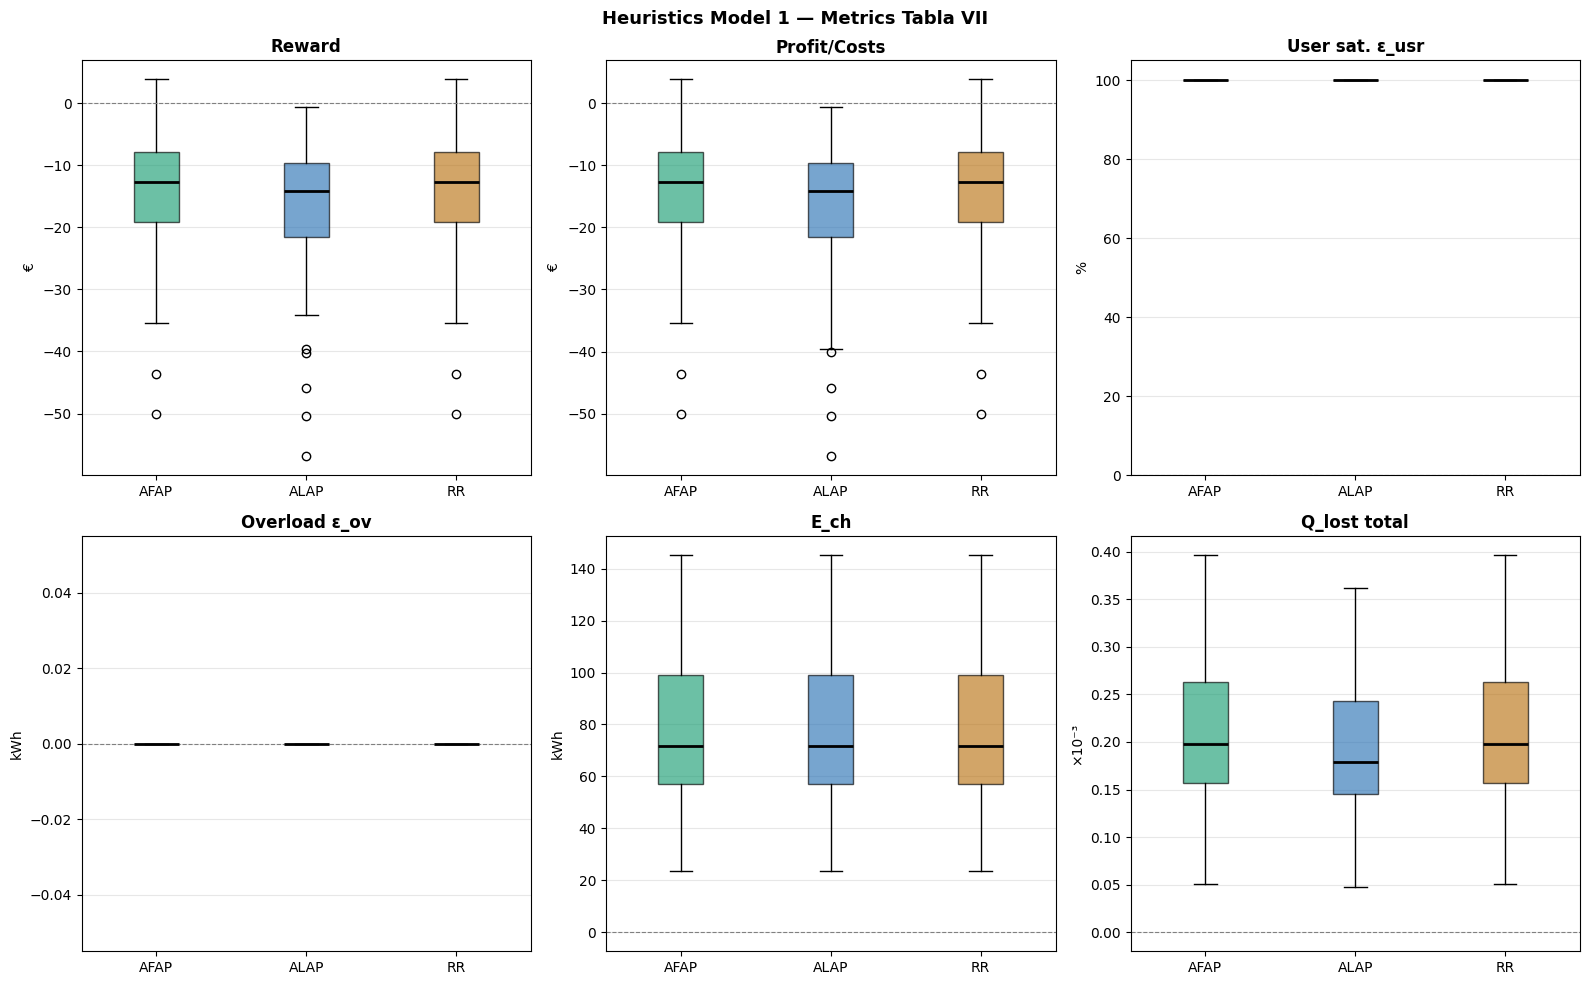

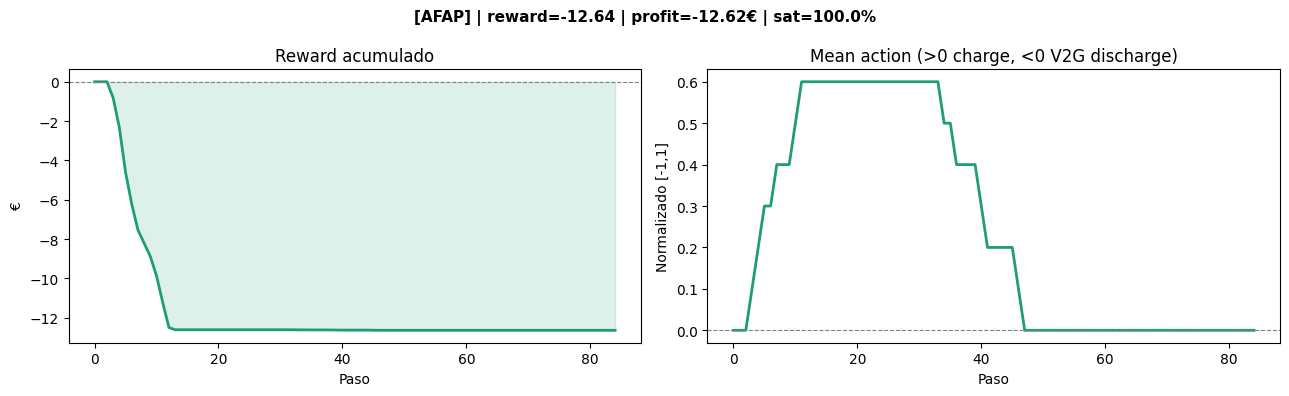

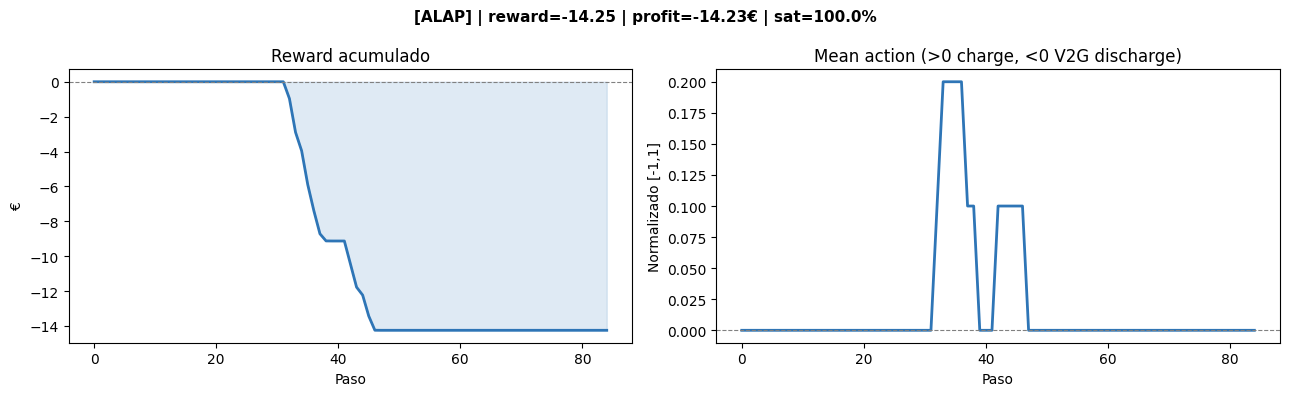

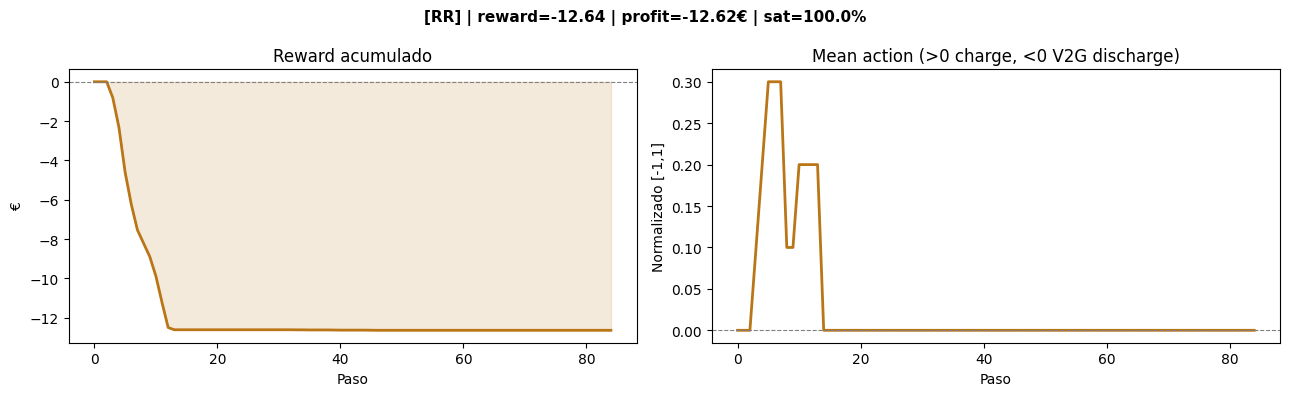

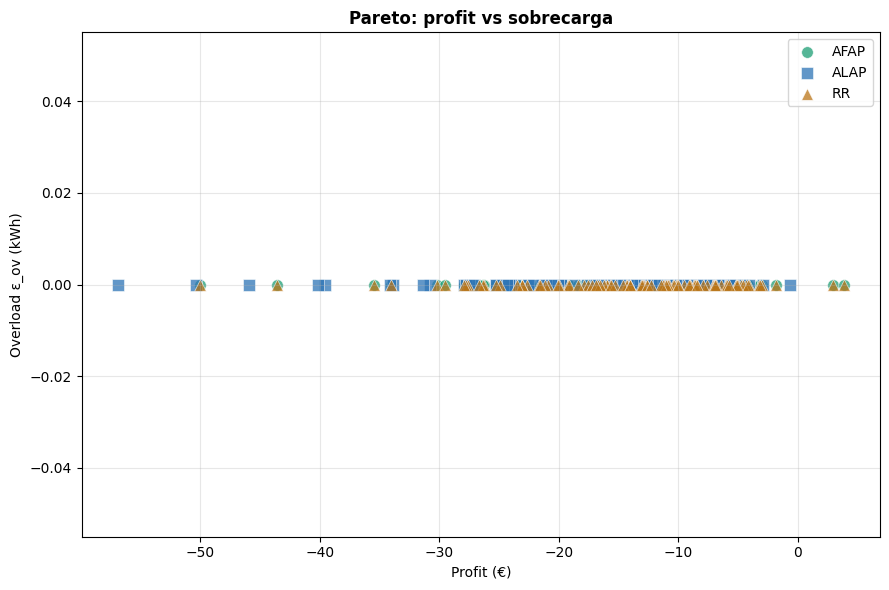

Plots saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Boxplots + traces and Pareto front
# ─────────────────────────────────────────────────────────────────────────────

def get_col(eps, col): return [e[col] for e in eps]

colors  = ['#1D9E75', '#2E75B6', '#BA7517']
markers = ['o', 's', '^']
labels_box = list(results.keys())

metrics_box = [
    ('reward_total',             'Reward',           '€',      1,    False),
    ('total_profit_cost',        'Profit/Costs',     '€',      1,    False),
    ('user_satisfaction',        'User sat. ε_usr',  '%',      100,  True),
    ('transformer_overload_kwh', 'Overload ε_ov',    'kWh',    1,    False),
    ('energy_charged_kwh',       'E_ch',             'kWh',    1,    False),
    ('battery_degradation',      'Q_lost total',     '×10⁻³', 1e3,  False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (col, title_m, unit, mult, is_sat) in zip(axes.flat, metrics_box):
    data = [[v*mult for v in get_col(eps, col)] for eps in results.values()]
    bp = ax.boxplot(data, labels=labels_box, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    if is_sat: ax.set_ylim(0, 105)
    ax.set_title(title_m, fontweight='bold')
    ax.set_ylabel(unit)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Heuristics Model 1 — Metrics Tabla VII',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'boxplots_tabla7.png', dpi=150, bbox_inches='tight')
plt.show()

def plot_traces(episodes, label, color, path):
    if not episodes: return
    r_arr = np.array([e['reward_total'] for e in episodes])
    rep   = episodes[int(np.argmin(np.abs(r_arr - np.median(r_arr))))]
    steps = np.arange(len(rep['ts_reward']))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(steps, rep['ts_cum_reward'], color=color, lw=2)
    axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0].fill_between(steps, rep['ts_cum_reward'], alpha=0.15, color=color)
    axes[0].set_title('Reward acumulado')
    axes[0].set_xlabel('Paso'); axes[0].set_ylabel('€')
    axes[1].plot(steps, rep['ts_action'], color=color, lw=2)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_title('Mean action (>0 charge, <0 V2G discharge)')
    axes[1].set_xlabel('Paso'); axes[1].set_ylabel('Normalizado [-1,1]')
    fig.suptitle(
        f'[{label}] | reward={rep["reward_total"]:+.2f} | '
        f'profit={rep["total_profit_cost"]:+.2f}€ | '
        f'sat={rep["user_satisfaction"]:.1%}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

for i, (label, eps) in enumerate(results.items()):
    plot_traces(eps, label, colors[i],
                RESULTS_ROOT / f'traces_{label.lower()}.png')

# ── Pareto: profit vs overload ────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(9, 6))
for i, (label, eps) in enumerate(results.items()):
    ax.scatter(
        get_col(eps, 'total_profit_cost'),
        get_col(eps, 'transformer_overload_kwh'),
        label=label, alpha=0.75, s=70, color=colors[i],
        marker=markers[i], edgecolors='white', linewidths=0.5
    )
ax.set_xlabel('Profit (€)')
ax.set_ylabel('Overload ε_ov (kWh)')
ax.set_title('Pareto: profit vs sobrecarga', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Exportar Excel + CSV + reproducibility log
# ─────────────────────────────────────────────────────────────────────────────

def eps_to_df(episodes, label):
    rows = [{k: v for k, v in e.items()
             if k in SCALAR_COLS + ['episode', 'seed', 'agent']}
            for e in episodes]
    df = pd.DataFrame(rows)
    df.insert(0, 'algorithm', label)
    return df

def tabla7_row(episodes, label):
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS}
                        for e in episodes])
    row = {'Algorithm': label}
    for col in SCALAR_COLS:
        if col in df.columns:
            row[f'{col}_mean'] = round(df[col].mean(), 6)
            row[f'{col}_std']  = round(df[col].std(ddof=1) if len(df)>1 else 0.0, 6)
    return row

# ── Paper reference values (verified against Table VII) ───────────────────────
# Previously ALAP profit=0.5±2.8 and RR profit=-1.4±3.3 with overload=0.
# Correct Table VII values restored below.
paper_refs = {
    'AFAP': {
        'total_profit_cost_mean': -23.4, 'total_profit_cost_std': 6.4,
        'user_satisfaction_mean': 1.0,   'user_satisfaction_std': 0.0,
        'transformer_overload_kwh_mean': 138.0, 'transformer_overload_kwh_std': 86.0,
        'battery_degradation_mean': 0.40e-3,    'battery_degradation_std': 0.09e-3,
        'reward_total_mean': -13800.0, 'reward_total_std': 8600.0,
    },
    'ALAP': {
        'total_profit_cost_mean': -25.2, 'total_profit_cost_std': 7.1,
        'user_satisfaction_mean': 1.0,   'user_satisfaction_std': 0.0,
        'transformer_overload_kwh_mean': 106.0, 'transformer_overload_kwh_std': 78.0,
        'battery_degradation_mean': 0.38e-3,    'battery_degradation_std': 0.09e-3,
        'reward_total_mean': None, 'reward_total_std': None,
    },
    'RR': {
        'total_profit_cost_mean': -22.6, 'total_profit_cost_std': 5.6,
        'user_satisfaction_mean': 0.99,  'user_satisfaction_std': 0.02,
        'transformer_overload_kwh_mean': 11.0, 'transformer_overload_kwh_std': 19.0,
        'battery_degradation_mean': 0.45e-3,   'battery_degradation_std': 0.10e-3,
        'reward_total_mean': None, 'reward_total_std': None,
    },
}

own_rows   = [tabla7_row(e, l) for l, e in results.items()]
paper_rows = [{'Algorithm': f'Paper_{k}_ref', **v} for k, v in paper_refs.items()]

df_eps_all  = pd.concat([eps_to_df(e, l) for l, e in results.items()],
                         ignore_index=True)
df_tabla7   = pd.DataFrame(own_rows + paper_rows)
df_all_sum2 = pd.concat([summarise(e, l) for l, e in results.items()],
                          ignore_index=True)
df_regime   = pd.concat(list(dfs_eps.values()), ignore_index=True)

# ── Update and save REPRO_LOG ─────────────────────────────────────────────────
REPRO_LOG.update({
    'total_episodes_per_agent': EVAL_EPISODES,
    'agents_evaluated': list(results.keys()),
    'episodes_collected': {k: len(v) for k, v in results.items()},
})
with open(RESULTS_ROOT / 'reproducibility_log.json', 'w') as f:
    json.dump(REPRO_LOG, f, indent=2)
print('Reproducibility log saved.')

# ── Export Excel ──────────────────────────────────────────────────────────────
out = RESULTS_ROOT / 'heuristics_model1_report.xlsx'
with pd.ExcelWriter(out) as w:
    df_eps_all.to_excel( w, sheet_name='episodes_all',    index=False)
    df_tabla7.to_excel(  w, sheet_name='tabla7_vs_paper', index=False)
    df_all_sum2.to_excel(w, sheet_name='summary_full',    index=False)
    df_regime.to_excel(  w, sheet_name='regime_analysis', index=False)
print(f'Excel report: {out}')
df_eps_all.to_csv(RESULTS_ROOT / 'episodes_all.csv',    index=False)
df_tabla7.to_csv( RESULTS_ROOT / 'tabla7_vs_paper.csv', index=False)
print('CSVs saved.')


Reproducibility log saved.
Excel report: results_heuristics_model1/heuristics_model1_report.xlsx
CSVs saved.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────────────────────────────────────

def arr2(eps, col): return np.array([e[col] for e in eps])
def fmt2(a, mult=1):
    return (f'{a.mean()*mult:+.2f} ± {a.std(ddof=1)*mult:.2f}'
            if len(a) > 1 else f'{a.mean()*mult:+.2f} (n=1)')

sep = '=' * 75
print(sep)
print('  HEURISTICS Model 1 — FINAL SUMMARY')
print(f'  Episodios: {EVAL_EPISODES} ({len(EVAL_SEEDS)} seeds × {EPISODES_PER_SEED})')
print(sep)
header = f"  {'Metric':<28}"
for ag in results: header += f' {ag:>22}'
print(header)
print(f'  {"-"*72}')
for lbl, col, mult in [
    ('Reward',          'reward_total',             1),
    ('Profit (€)',       'total_profit_cost',        1),
    ('User sat. (%)',    'user_satisfaction',        100),
    ('Overload (kWh)',   'transformer_overload_kwh', 1),
    ('Q_lost (×10⁻³)', 'battery_degradation',      1e3),
    ('E_ch (kWh)',       'energy_charged_kwh',       1),
    ('E_dis (kWh)',      'energy_discharged_kwh',    1),
]:
    row = f'  {lbl:<28}'
    for label, eps in results.items():
        row += f' {fmt2(arr2(eps, col), mult):>22}'
    print(row)

print(sep)
print('  PAPER REF (Table VII):')
print('  AFAP: profit=-23.4±6.4€  sat=100%  overload=138±86kWh  Qlost≈0.40×10⁻³')
print('  ALAP: profit=-25.2±7.1€  sat=100%  overload=106±78kWh  Qlost≈0.38×10⁻³')
print('  RR:   profit=-22.6±5.6€  sat=99%   overload=11±19kWh   Qlost≈0.45×10⁻³')
print(sep)

# ── Statistical caution ──────────────────────────────────────────────────────
print('\nSTATISTICAL NOTE:')
for agent_name, eps in results.items():
    pr = arr2(eps, 'total_profit_cost')
    if len(pr) > 1:
        mn, sd = pr.mean(), pr.std(ddof=1)
        flag = ' ← std > mean, treat as directional only' \
               if abs(sd) > abs(mn) and mn != 0 else ''
        print(f'  {agent_name} Profit: {mn:+.2f} ± {sd:.2f}€{flag}')
print('NOTE: RR profit=0.0±0.0 is a low-complexity reference — no conclusions drawn.')
print(sep)
print('Output files:')
for f in sorted(RESULTS_ROOT.glob('*')):
    if f.is_file(): print(f'  {f.name}')


  HEURISTICS Model 1 — FINAL SUMMARY
  Episodios: 100 (5 seeds × 20)
  Metric                                         AFAP                   ALAP                     RR
  ------------------------------------------------------------------------
  Reward                                -14.23 ± 9.24         -16.62 ± 10.20          -14.23 ± 9.24
  Profit (€)                            -14.21 ± 9.24         -16.60 ± 10.19          -14.21 ± 9.24
  User sat. (%)                        +100.00 ± 0.00         +100.00 ± 0.00         +100.00 ± 0.00
  Overload (kWh)                         +0.00 ± 0.00           +0.00 ± 0.00           +0.00 ± 0.00
  Q_lost (×10⁻³)                         +0.20 ± 0.07           +0.19 ± 0.06           +0.20 ± 0.07
  E_ch (kWh)                           +77.06 ± 27.99         +77.06 ± 27.99         +77.06 ± 27.99
  E_dis (kWh)                            +0.00 ± 0.00           +0.00 ± 0.00           +0.00 ± 0.00
  PAPER REF (Table VII):
  AFAP: profit=-23.4±6.4€  sat=